##
Autoregressive Process.

In [1]:
import numpy as np
import matplotlib.pyplot as plt 

In [4]:
def autoregressive_synthese_pro(N, coeffs, variance, burn_in=100):
    p = len(coeffs)
    sigma = np.sqrt(variance)
    
    longueur_totale = N + burn_in
    
    # wE initialize with gaussian
    X = [np.random.normal(0, sigma) for _ in range(p)]
    
    # 2. we generate the whole series
    for i in range(p, longueur_totale):
        valeur_actuelle = 0
        
        # we apply the formulate
        for j in range(p):
            valeur_actuelle += coeffs[j] * X[i - 1 - j]
            
        # we add the noise
        valeur_actuelle += np.random.normal(0, sigma)
        X.append(valeur_actuelle)
        
    # We thrown the burn_in first elements
    # we only return from burn in, so we start from an ar set.
    return X[burn_in : burn_in + N]

In [18]:
import numpy as np

def periodogram(signal, Bartlett, Welch, mu, L):
    N = len(signal)
   
    if Bartlett:
        M = N // L
        sommetotale = 0
        for i in range(L):
            sommeM = 0
            for j in range(M):
                sommeM += signal[i * M + j] * np.exp(-2 * 1j * np.pi * mu * j)
            
            sommetotale += (1 / M) * np.abs(sommeM)**2
            
        return (1 / L) * sommetotale

    elif Welch:
        M = N // L
        shift = M // 2
        K = (N - M) // shift + 1
        window = np.hamming(M)
        U = np.sum(window**2) / M
        sommetotale = 0
        
        for i in range(K):
            sommeM = 0
            for j in range(M):
                sommeM += signal[i * shift + j] * window[j] * np.exp(-2 * 1j * np.pi * mu * j)
            
            sommetotale += (1 / (M * U)) * np.abs(sommeM)**2
            
        return (1 / K) * sommetotale

    else:
        somme = 0
        for i in range(N):
            somme += signal[i] * np.exp(-2 * 1j * np.pi * mu * i)
            
        return (1 / N) * np.abs(somme)**2

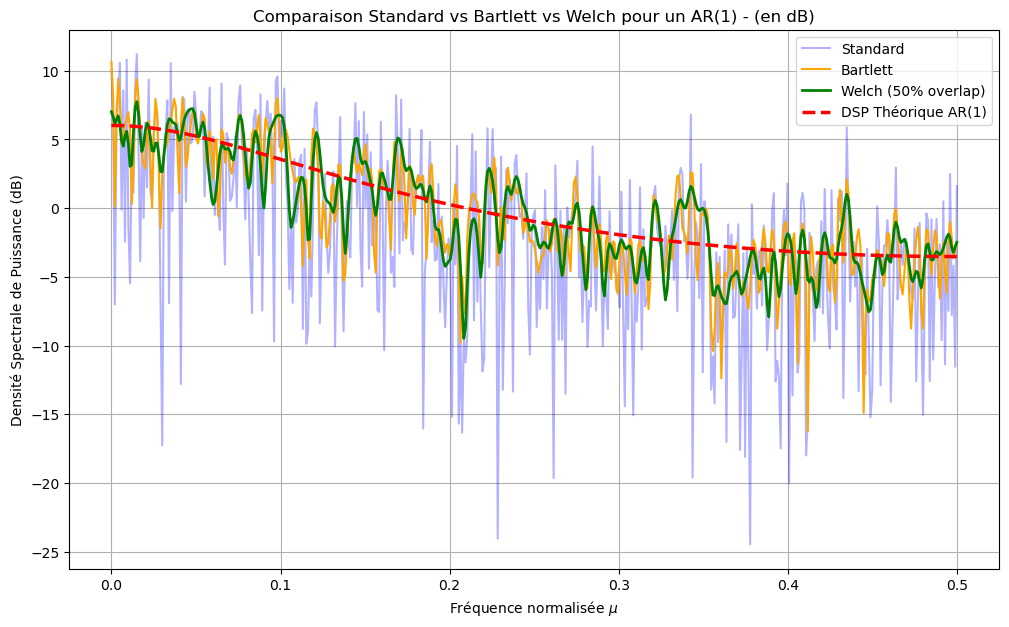

In [20]:

coeffs = [0.5] 
variance = 1
N = 1000
L = 3 # Nombre de sous-segments de base

# 1. Synthèse du signal AR
X = autoregressive_synthese_pro(N, coeffs, variance, burn_in=100)

# 2. Création de l'axe des fréquences (mu de 0 à 0.5)
mu_values = np.linspace(0, 0.5, 500)

Y_standard = []
Y_bartlett = []
Y_welch = []


# 3. Calcul des périodogrammes pour chaque fréquence
for mu in mu_values:
    Y_standard.append(periodogram(X, False, False, mu, L))
    Y_bartlett.append(periodogram(X, True, False, mu, L))
    Y_welch.append(periodogram(X, False, True, mu, L))

# On convertit les listes en tableaux NumPy
Y_standard = np.array(Y_standard)
Y_bartlett = np.array(Y_bartlett)
Y_welch = np.array(Y_welch)

# 4. Calcul de la DSP théorique
exponentielle = np.exp(-2 * 1j * np.pi * mu_values)
psd_theorique = variance / (np.abs(1 - coeffs[0] * exponentielle)**2)


# 5. Conversion en dB
Y_standard_dB = 10 * np.log10(Y_standard)
Y_bartlett_dB = 10 * np.log10(Y_bartlett)
Y_welch_dB = 10 * np.log10(Y_welch)
psd_theorique_dB = 10 * np.log10(psd_theorique)

# 6. Affichage
plt.figure(figsize=(12, 7))

# Le standard (très bruité)
plt.plot(mu_values, Y_standard_dB, label='Standard', alpha=0.3, color='blue')

# Bartlett (segments découpés sans chevauchement)
plt.plot(mu_values, Y_bartlett_dB, label=f'Bartlett', linewidth=1.5, color='orange')

# Welch (segments avec chevauchement et fenêtrage de Hamming)
plt.plot(mu_values, Y_welch_dB, label=f'Welch (50% overlap)', linewidth=2, color='green')

# La DSP Théorique
plt.plot(mu_values, psd_theorique_dB, label='DSP Théorique AR(1)', linestyle='dashed', color='red', linewidth=2.5)

plt.title("Comparaison Standard vs Bartlett vs Welch pour un AR(1) - (en dB)")
plt.xlabel("Fréquence normalisée $\mu$")
plt.ylabel("Densité Spectrale de Puissance (dB)")
plt.legend()
plt.grid(True)
plt.show()

In [21]:

coeffs = [0.5] 
variance = 1
N = 1000
L = 3
nb_realisations = 100 

mu_values = np.linspace(0, 0.5, 100) 
all_Y_standard = np.zeros((nb_realisations, len(mu_values)))
all_Y_bartlett = np.zeros((nb_realisations, len(mu_values)))
all_Y_welch = np.zeros((nb_realisations, len(mu_values)))



for r in range(nb_realisations):
    X = autoregressive_synthese_pro(N, coeffs, variance, burn_in=100)
    
    for idx, mu in enumerate(mu_values):
        all_Y_standard[r, idx] = periodogram(X, False, False, mu, L)
        all_Y_bartlett[r, idx] = periodogram(X, True, False, mu, L)
        all_Y_welch[r, idx] = periodogram(X, False, True, mu, L)


# On calcule la vraie PSD théorique
exponentielle = np.exp(-2 * 1j * np.pi * mu_values)
psd_theorique = variance / (np.abs(1 - coeffs[0] * exponentielle)**2)

mean_standard = np.mean(all_Y_standard, axis=0)
mean_bartlett = np.mean(all_Y_bartlett, axis=0)
mean_welch = np.mean(all_Y_welch, axis=0)


biais_standard = np.mean(np.abs(mean_standard - psd_theorique))
biais_bartlett = np.mean(np.abs(mean_bartlett - psd_theorique))
biais_welch = np.mean(np.abs(mean_welch - psd_theorique))

var_standard = np.mean(np.var(all_Y_standard, axis=0))
var_bartlett = np.mean(np.var(all_Y_bartlett, axis=0))
var_welch = np.mean(np.var(all_Y_welch, axis=0))

print(f"Results")
print(f"STANDARD : Biais = {biais_standard:.4f} | Variance = {var_standard:.4f}")
print(f"BARTLETT : Biais = {biais_bartlett:.4f} | Variance = {var_bartlett:.4f}")
print(f"WELCH    : Biais = {biais_welch:.4f} | Variance = {var_welch:.4f}")

--- RÉSULTATS (Scores moyens) ---
STANDARD : Biais = 0.1116 | Variance = 3.2047
BARTLETT : Biais = 0.0623 | Variance = 1.0324
WELCH    : Biais = 0.0577 | Variance = 0.6720


In [25]:
import librosa

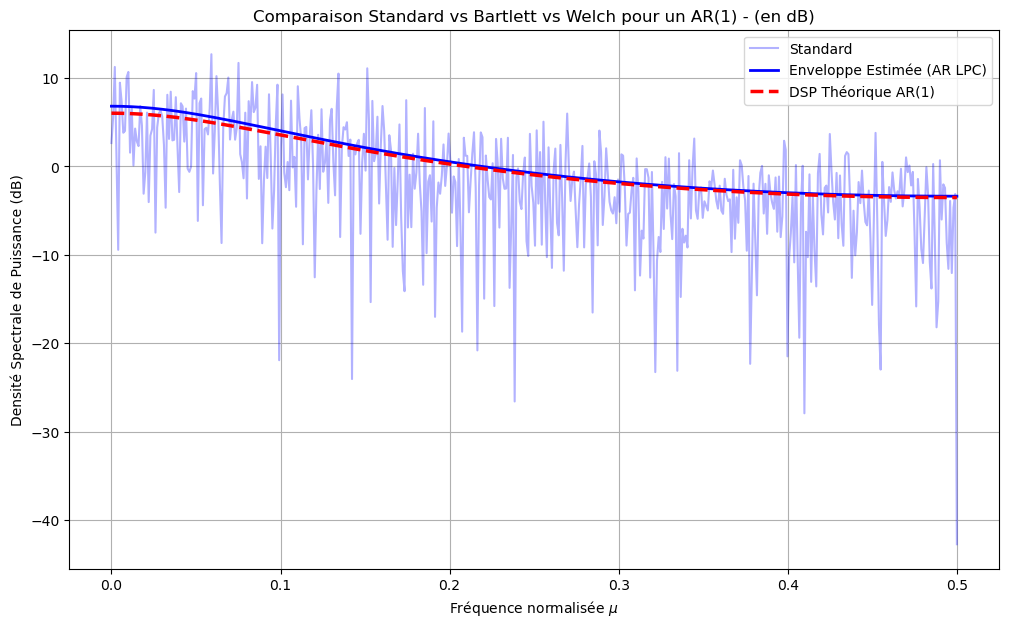

In [ ]:





coeffs = [0.5] 
variance = 1
N = 1000
L = 3 # Nombre de sous-segments de base

# 1. Synthèse du signal AR
X = autoregressive_synthese_pro(N, coeffs, variance, burn_in=100)

# 2. Création de l'axe des fréquences (mu de 0 à 0.5)
mu_values = np.linspace(0, 0.5, 500)

Y_standard = []



# 3. Calcul des périodogrammes pour chaque fréquence
for mu in mu_values:
    Y_standard.append(periodogram(X, False, False, mu, L))
  

# On convertit les listes en tableaux NumPy
Y_standard = np.array(Y_standard)

y=np.array(X)
a_lpc= librosa.lpc(y,order=1)


# 4. Calcul de la DSP théorique
exponentielle = np.exp(-2 * 1j * np.pi * mu_values)
psd_theorique = variance / (np.abs(1 - coeffs[0] * exponentielle)**2)

residu = y[1:] + a_lpc[1] * y[:-1]
variance_estimee = np.var(residu)
psd_estimee = variance_estimee / (np.abs(a_lpc[0] + a_lpc[1] * exponentielle)**2)


# 5. Conversion en dB
Y_standard_dB = 10 * np.log10(Y_standard)

psd_theorique_dB = 10 * np.log10(psd_theorique)

plt.figure(figsize=(12, 7))

plt.plot(mu_values, Y_standard_dB, label='Standard', alpha=0.3, color='blue')

plt.plot(mu_values, 10 * np.log10(psd_estimee), label='Enveloppe Estimée (AR LPC)', color='blue', linewidth=2)
plt.plot(mu_values, psd_theorique_dB, label='DSP Théorique AR(1)', linestyle='dashed', color='red', linewidth=2.5)

plt.title("Comparaison Standard vs Bartlett vs Welch pour un AR(1) - (en dB)")
plt.xlabel("Fréquence normalisée $\mu$")
plt.ylabel("Densité Spectrale de Puissance (dB)")
plt.legend()
plt.grid(True)
plt.show()



Le standard  est très bruité, le lpc de la bibliothèque librosa est bien plus proche de la réalité.

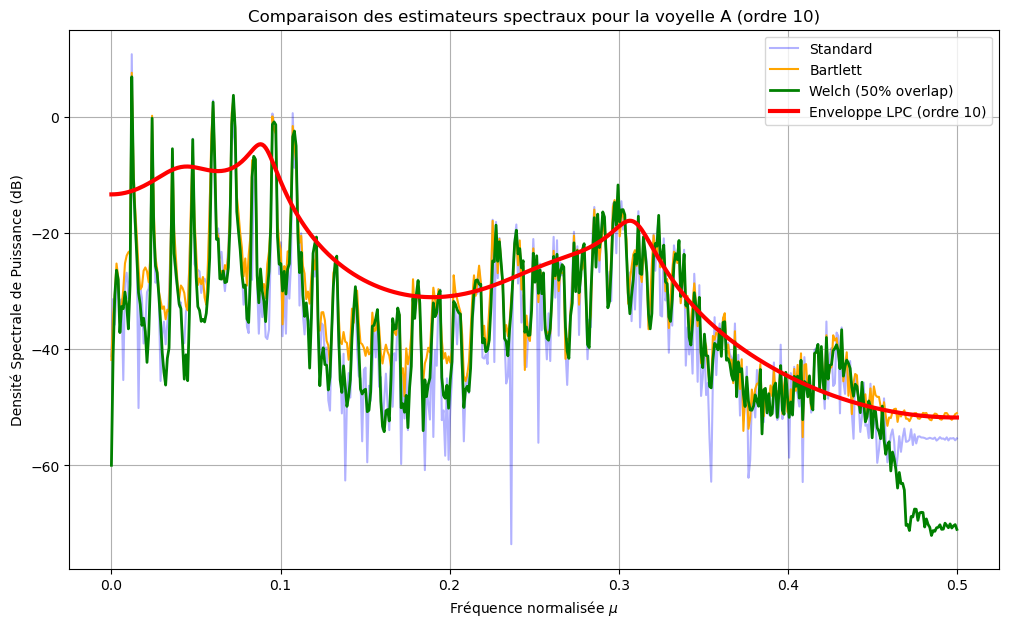

In [50]:
from scipy.signal import lfilter

y, sr = librosa.load('aeiou.wav', sr=None)
y_a = y[0:12450]
L = 3
order = 10
mu_values = np.linspace(0, 0.5, 500)

Y_standard = []
Y_bartlett = []
Y_welch = []

for mu in mu_values:
    Y_standard.append(periodogram(y_a, False, False, mu, L))
    Y_bartlett.append(periodogram(y_a, True, False, mu, L))
    Y_welch.append(periodogram(y_a, False, True, mu, L))

Y_standard = np.array(Y_standard)
Y_bartlett = np.array(Y_bartlett)
Y_welch = np.array(Y_welch)

a_lpc = librosa.lpc(y_a, order=order)
residu = lfilter(a_lpc, [1.0], y_a)
variance_estimee = np.var(residu)

k = np.arange(len(a_lpc))
exposant = -2 * 1j * np.pi * np.outer(mu_values, k)
A_mu = np.dot(np.exp(exposant), a_lpc)
psd_estimee = variance_estimee / (np.abs(A_mu)**2)

Y_standard_dB = 10 * np.log10(Y_standard)
Y_bartlett_dB = 10 * np.log10(Y_bartlett)
Y_welch_dB = 10 * np.log10(Y_welch)
psd_estimee_dB = 10 * np.log10(psd_estimee)

plt.figure(figsize=(12, 7))
plt.plot(mu_values, Y_standard_dB, label='Standard', alpha=0.3, color='blue')
plt.plot(mu_values, Y_bartlett_dB, label='Bartlett', linewidth=1.5, color='orange')
plt.plot(mu_values, Y_welch_dB, label='Welch (50% overlap)', linewidth=2, color='green')
plt.plot(mu_values, psd_estimee_dB, label=f'Enveloppe LPC (ordre {order})', color='red', linewidth=3)

plt.title(f"Comparaison des estimateurs spectraux pour la voyelle A (ordre {order})")
plt.xlabel("Fréquence normalisée $\mu$")
plt.ylabel("Densité Spectrale de Puissance (dB)")
plt.legend()
plt.grid(True)
plt.show()

Partie 2 

In [ ]:
def noisy_synthese(N, K, frequences, amplitudes, phases, variance):
    n = np.arange(N)
    
    signal_total = np.zeros(N)
    
    for i in range(K):
        composante = amplitudes[i] * np.cos(2 * np.pi * frequences[i] * n + phases[i])
        signal_total += composante
        
   
    bruit = np.random.normal(0, np.sqrt(variance), N)
    
    return signal_total + bruit


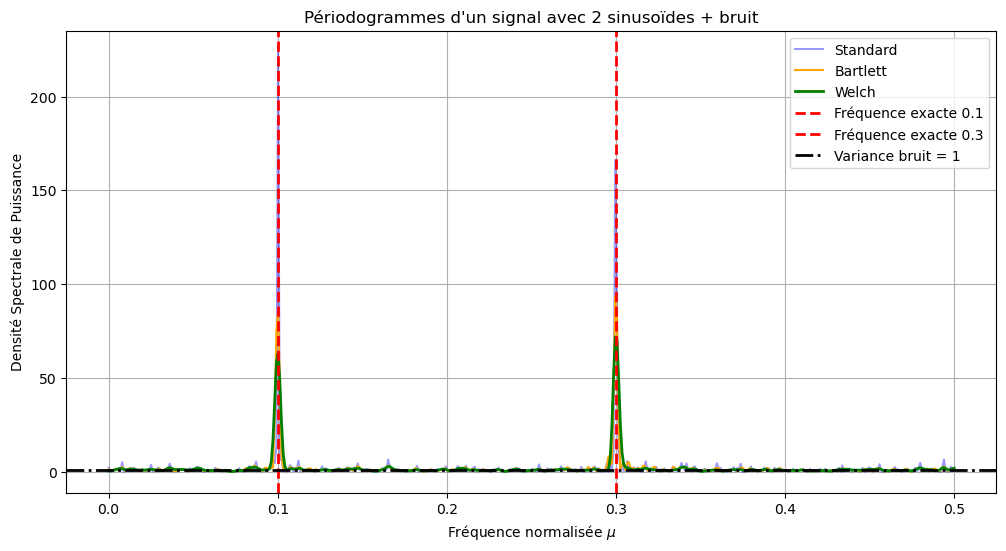

In [ ]:
mu1 = 0.1
mu2 = 0.3
amplitudes = [1, 1]
variance = 1
L = 3
N = 1000

x = noisy_synthese(N, 2, [mu1, mu2], amplitudes, [0, 0], variance)


mu_values = np.linspace(0, 0.5, 500)

Y_standard = []
Y_bartlett = []
Y_welch = []

for mu in mu_values:
    Y_standard.append(periodogram(x, False, False, mu, L))
    Y_bartlett.append(periodogram(x, True, False, mu, L))
    Y_welch.append(periodogram(x, False, True, mu, L))

plt.figure(figsize=(12, 6))

plt.plot(mu_values, Y_standard, label='Standard', alpha=0.4, color='blue')
plt.plot(mu_values, Y_bartlett, label='Bartlett', linewidth=1.5, color='orange')
plt.plot(mu_values, Y_welch, label='Welch', linewidth=2, color='green')

plt.axvline(x=mu1, color='red', linestyle='--', linewidth=2, label=f'Fréquence exacte {mu1}')
plt.axvline(x=mu2, color='red', linestyle='--', linewidth=2, label=f'Fréquence exacte {mu2}')

plt.axhline(y=variance, color='black', linestyle='-.', linewidth=2, label=f'Variance bruit = {variance}')

plt.title("Périodogrammes d'un signal avec 2 sinusoïdes + bruit")
plt.xlabel("Fréquence normalisée $\mu$")
plt.ylabel("Densité Spectrale de Puissance")
plt.legend()
plt.grid(True)
plt.show()

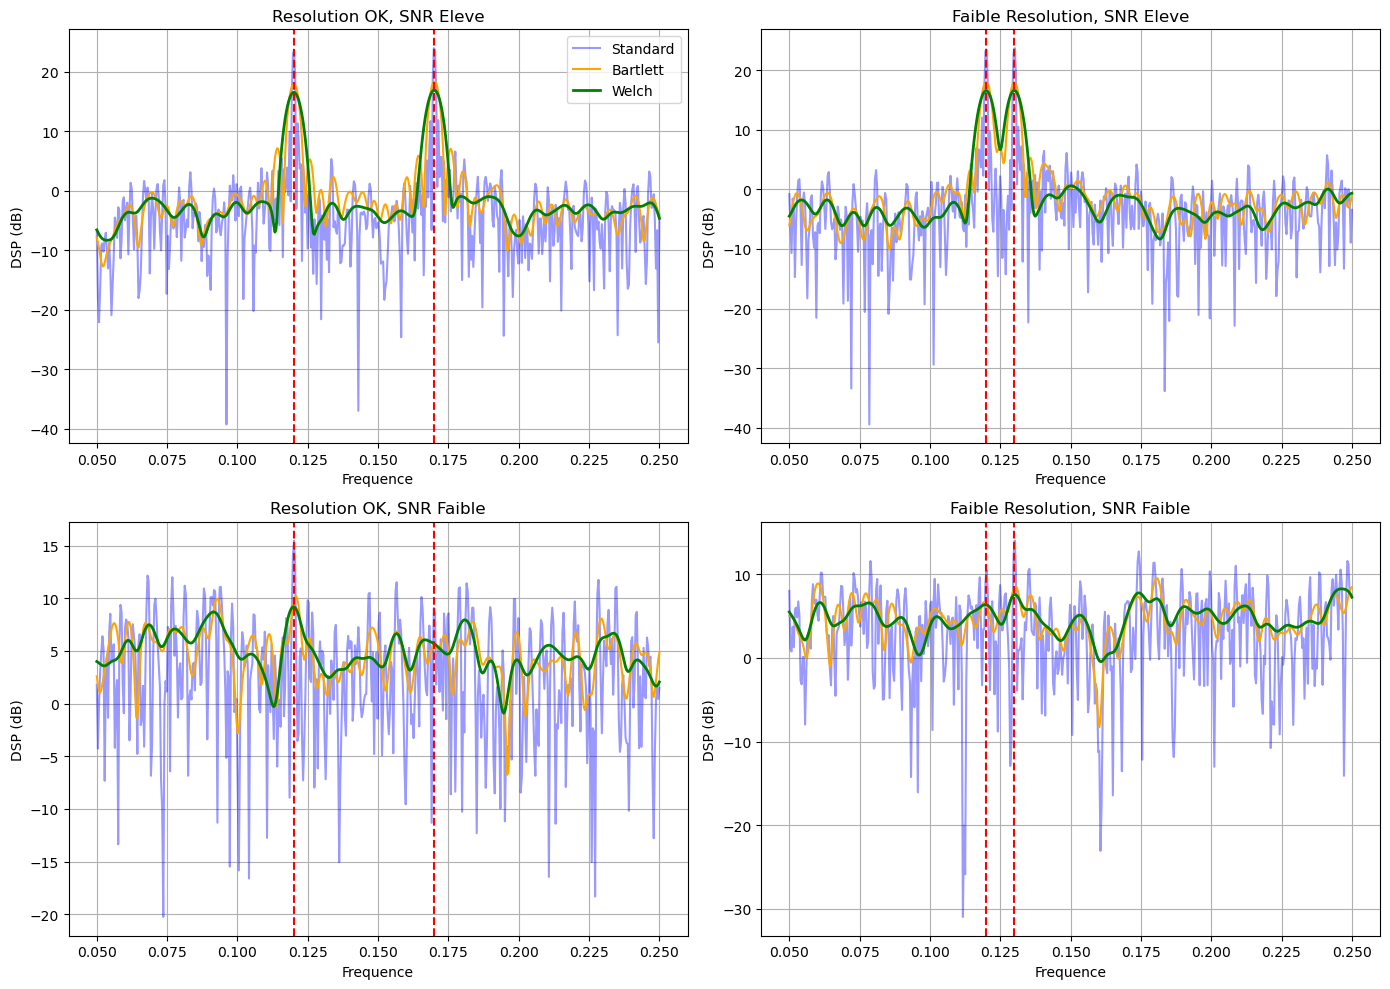

In [53]:
import numpy as np
import matplotlib.pyplot as plt

N = 1000
L = 4
mu_values = np.linspace(0.05, 0.25, 500)

configs = [
    {"mu1": 0.12, "mu2": 0.17, "amp": 1.0, "var": 0.5, "title": "Resolution OK, SNR Eleve"},
    {"mu1": 0.12, "mu2": 0.13, "amp": 1.0, "var": 0.5, "title": "Faible Resolution, SNR Eleve"},
    {"mu1": 0.12, "mu2": 0.17, "amp": 0.3, "var": 3.0, "title": "Resolution OK, SNR Faible"},
    {"mu1": 0.12, "mu2": 0.13, "amp": 0.3, "var": 3.0, "title": "Faible Resolution, SNR Faible"}
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, conf in enumerate(configs):
    x = noisy_synthese(N, 2, [conf["mu1"], conf["mu2"]], [conf["amp"], conf["amp"]], [0, 0], conf["var"])
    
    Y_std = np.array([periodogram(x, False, False, mu, L) for mu in mu_values])
    Y_bart = np.array([periodogram(x, True, False, mu, L) for mu in mu_values])
    Y_welch = np.array([periodogram(x, False, True, mu, L) for mu in mu_values])
    
    axes[i].plot(mu_values, 10 * np.log10(Y_std), label='Standard', alpha=0.4, color='blue')
    axes[i].plot(mu_values, 10 * np.log10(Y_bart), label='Bartlett', linewidth=1.5, color='orange')
    axes[i].plot(mu_values, 10 * np.log10(Y_welch), label='Welch', linewidth=2, color='green')
    
    axes[i].axvline(conf["mu1"], color='red', linestyle='--')
    axes[i].axvline(conf["mu2"], color='red', linestyle='--')
    
    axes[i].set_title(conf["title"])
    axes[i].set_xlabel("Frequence")
    axes[i].set_ylabel("DSP (dB)")
    axes[i].grid(True)
    if i == 0:
        axes[i].legend()

plt.tight_layout()
plt.show()

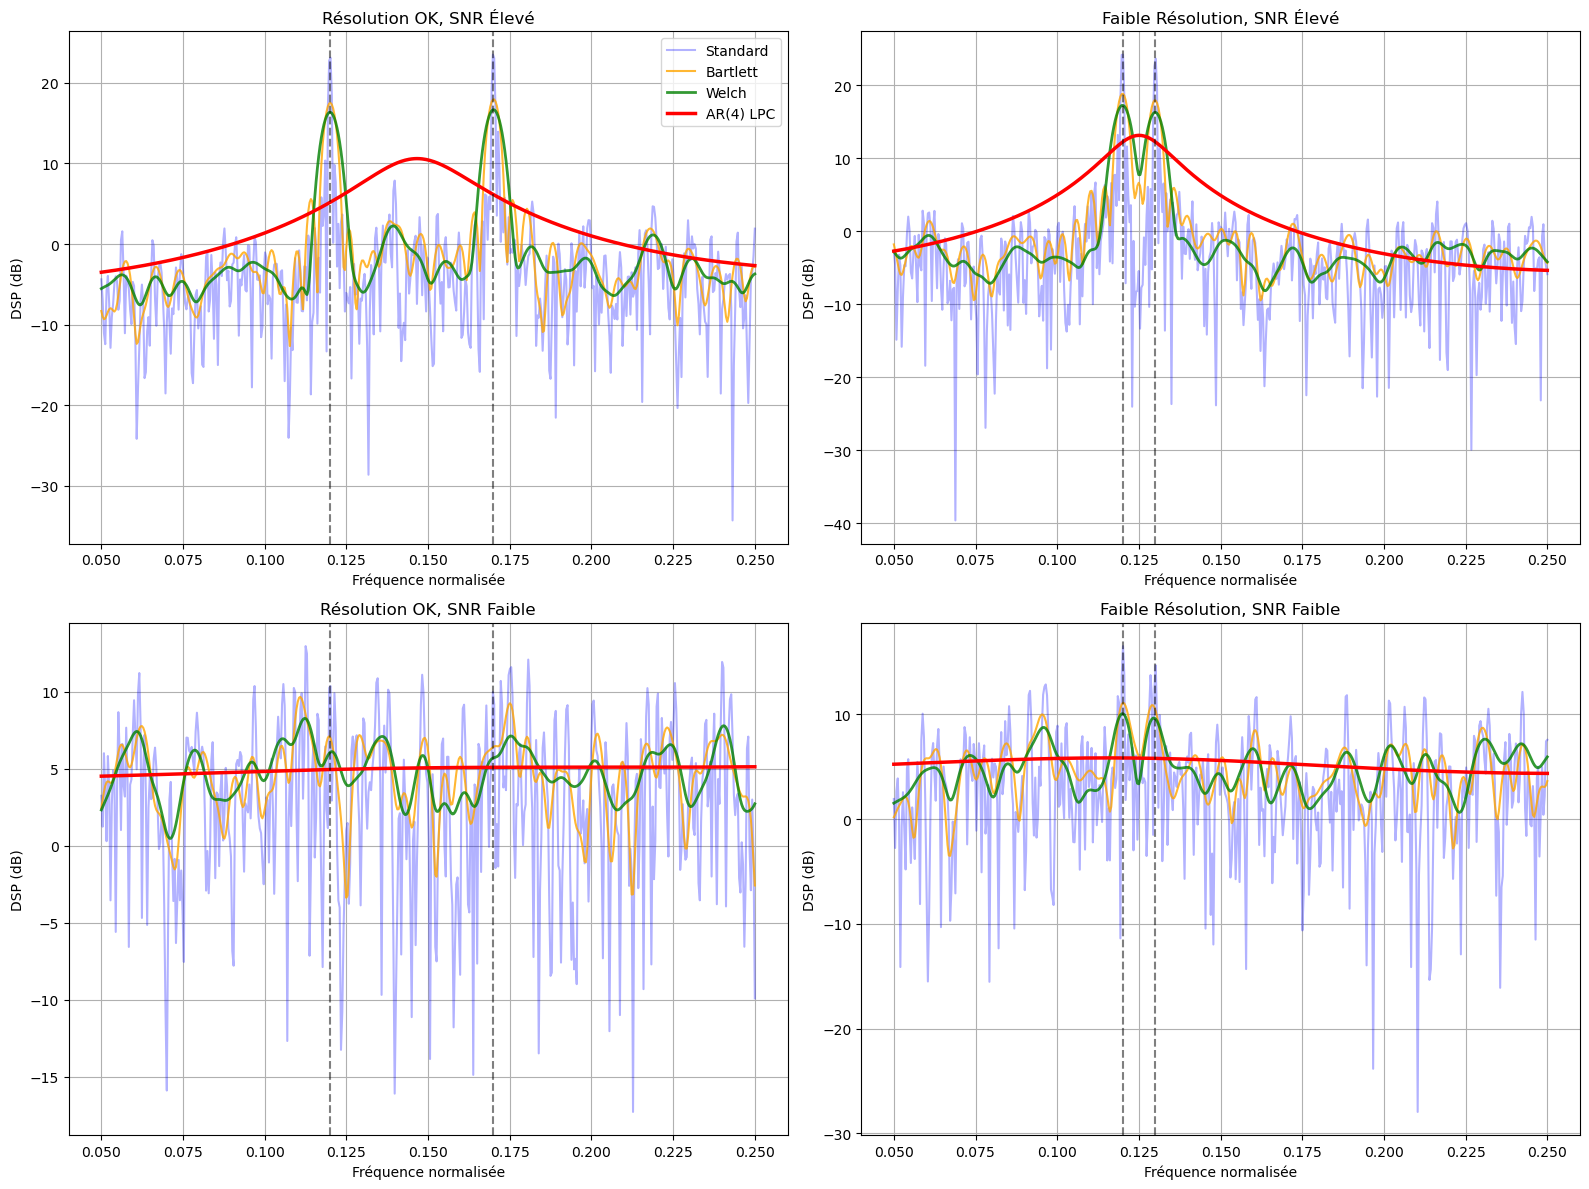

In [54]:
# Paramètres généraux
N = 1000
L = 4
mu_values = np.linspace(0.05, 0.25, 500)
order = 4

# Les 4 configurations (Delta Nu et SNR)
configs = [
    {"mu1": 0.12, "mu2": 0.17, "amp": 1.0, "var": 0.5, "title": "Résolution OK, SNR Élevé"},
    {"mu1": 0.12, "mu2": 0.13, "amp": 1.0, "var": 0.5, "title": "Faible Résolution, SNR Élevé"},
    {"mu1": 0.12, "mu2": 0.17, "amp": 0.3, "var": 3.0, "title": "Résolution OK, SNR Faible"},
    {"mu1": 0.12, "mu2": 0.13, "amp": 0.3, "var": 3.0, "title": "Faible Résolution, SNR Faible"}
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, conf in enumerate(configs):
    # Génération du signal
    x = noisy_synthese(N, 2, [conf["mu1"], conf["mu2"]], [conf["amp"], conf["amp"]], [0, 0], conf["var"])
    
    # Estimateurs non-paramétriques
    Y_std = np.array([periodogram(x, False, False, mu, L) for mu in mu_values])
    Y_bart = np.array([periodogram(x, True, False, mu, L) for mu in mu_values])
    Y_welch = np.array([periodogram(x, False, True, mu, L) for mu in mu_values])
    
    # Estimateur paramétrique AR(4)
    a_lpc = librosa.lpc(x, order=order)
    residu = lfilter(a_lpc, [1.0], x)
    variance_estimee = np.var(residu)
    
    k = np.arange(len(a_lpc))
    exposant = -2 * 1j * np.pi * np.outer(mu_values, k)
    A_mu = np.dot(np.exp(exposant), a_lpc)
    psd_ar4 = variance_estimee / (np.abs(A_mu)**2)
    
    # Tracés (en dB)
    axes[i].plot(mu_values, 10 * np.log10(Y_std), label='Standard', alpha=0.3, color='blue')
    axes[i].plot(mu_values, 10 * np.log10(Y_bart), label='Bartlett', linewidth=1.5, color='orange', alpha=0.8)
    axes[i].plot(mu_values, 10 * np.log10(Y_welch), label='Welch', linewidth=2, color='green', alpha=0.8)
    axes[i].plot(mu_values, 10 * np.log10(psd_ar4), label='AR(4) LPC', linewidth=2.5, color='red')
    
    # Lignes de référence
    axes[i].axvline(conf["mu1"], color='black', linestyle='--', alpha=0.5)
    axes[i].axvline(conf["mu2"], color='black', linestyle='--', alpha=0.5)
    
    axes[i].set_title(conf["title"])
    axes[i].set_xlabel("Fréquence normalisée")
    axes[i].set_ylabel("DSP (dB)")
    axes[i].grid(True)
    if i == 0:
        axes[i].legend()

plt.tight_layout()
plt.show()

L'ajout du modèle paramétrique AR(4) met en évidence des différences fondamentales avec les méthodes non-paramétriques (Périodogrammes) en termes de compromis Résolution/Variance :La supériorité de la résolution paramétrique (SNR Élevé) : Contrairement aux méthodes de Bartlett et Welch dont la résolution est physiquement limitée par la taille de la fenêtre de découpage (limite de Rayleigh), le modèle AR n'a pas cette contrainte. Dans les cas à fort SNR, l'AR(4) offre une résolution exceptionnelle. Il est capable de séparer deux fréquences très proches ($\Delta\nu$ faible) là où Bartlett et Welch échouent et fusionnent les pics. Ses pics sont extrêmement fins et précis.La robustesse face au bruit (SNR Faible) :Dans des conditions de fort bruit, le Périodogramme Standard devient totalement inexploitable (trop de variance, apparition de faux pics). Le modèle AR(4), tout comme Welch, lisse le plancher de bruit de manière très efficace. Cependant, le modèle AR est forcé de modéliser le signal avec seulement 4 pôles. Si le bruit est trop important, les pôles du système s'éloignent du cercle unité : les pics de l'enveloppe AR(4) s'élargissent considérablement et perdent en résolution.Le cas extrême (Faible Résolution + SNR Faible) :Lorsque les fréquences sont très proches et noyées dans le bruit, le modèle AR(4) peine à distinguer les deux composantes et a tendance à ne modéliser qu'une seule cloche englobant les deux fréquences, se comportant alors de manière similaire aux méthodes de lissage par fenêtrage (Welch/Bartlett).Conclusion : La méthode de prédiction linéaire (AR d'ordre $p=2K$) est l'estimateur offrant le meilleur compromis global pour les signaux composés de sinusoïdes. Il allie la très haute résolution du Périodogramme Standard à la faible variance et la robustesse de la méthode de Welch, tant que le rapport signal-sur-bruit reste raisonnable.

## 2.3 Estimateur de Capon (MVDR)

On ajoute l’estimateur haute résolution de Capon (MVDR) et on compare sa capacité à séparer deux sinusoïdes proches quand on fait varier $\Delta\nu$ et le SNR (en dB), comme pour les méthodes précédentes.

In [ ]:
import numpy as np
from scipy.signal import lfilter
from scipy.linalg import toeplitz


def biased_autocorr(x, max_lag: int):
   
    x = np.asarray(x, dtype=np.complex128)
    N = x.size
    r = np.empty(max_lag + 1, dtype=np.complex128)
    for k in range(max_lag + 1):
        r[k] = np.vdot(x[: N - k], x[k:]) / N
    return r


def yule_walker_ar(x, order: int):
   
    if order < 1:
        return np.array([], dtype=float), float(np.var(x))

    r = biased_autocorr(x, order)
    R = toeplitz(r[:-1])
    rhs = r[1:]

    a = np.linalg.lstsq(R, rhs, rcond=None)[0]
    sigma2 = (r[0] - np.vdot(a, rhs)).real
    return a.real, float(max(sigma2, 1e-12))


def capon_spectrum(x, mu_values, m: int = 32, diagonal_loading: float = 1e-3):
    
    x = np.asarray(x, dtype=np.complex128)
    mu_values = np.asarray(mu_values, dtype=float)
    N = x.size
    if m < 2 or m >= N:
        raise ValueError

    # Data matrix with sliding windows (m x K)
    K = N - m + 1
    Xw = np.lib.stride_tricks.sliding_window_view(x, window_shape=m)
    Xw = Xw.T  # (m, K)

    R = (Xw @ Xw.conj().T) / K
    dl = diagonal_loading * (np.trace(R).real / m)
    R = R + dl * np.eye(m)
    Rinv = np.linalg.pinv(R)

    n = np.arange(m)
    A = np.exp(-2j * np.pi * np.outer(n, mu_values))  # (m, F)
    RA = Rinv @ A
    denom = np.sum(A.conj() * RA, axis=0)

    P = 1.0 / np.maximum(denom.real, 1e-18)
    return P


def arma_synthesis(N: int, ar, ma, sigma2: float, burn_in: int = 300):
    """Synthesize ARMA(p,q) with convention:

        x[n] = sum_{k=1..p} ar[k-1] x[n-k] + w[n] + sum_{k=1..q} ma[k-1] w[n-k]

    where w ~ N(0, sigma2).

    Accepts ar/ma with or without leading 1.
    """
    ar = np.atleast_1d(np.asarray(ar, dtype=float))
    ma = np.atleast_1d(np.asarray(ma, dtype=float))

    ar_params = ar[1:] if (ar.size >= 1 and np.isclose(ar[0], 1.0)) else ar
    ma_params = ma[1:] if (ma.size >= 1 and np.isclose(ma[0], 1.0)) else ma

    a = np.r_[1.0, -ar_params]  # A(z)=1 - sum ar_k z^{-k}
    b = np.r_[1.0, ma_params]   # B(z)=1 + sum ma_k z^{-k}

    w = np.random.normal(0.0, np.sqrt(sigma2), N + burn_in)
    x = lfilter(b, a, w)
    return x[burn_in : burn_in + N]


def arma_psd(mu_values, ar, ma, sigma2: float):
    """Exact PSD of ARMA under the same convention as arma_synthesis."""
    mu_values = np.asarray(mu_values, dtype=float)
    ar = np.atleast_1d(np.asarray(ar, dtype=float))
    ma = np.atleast_1d(np.asarray(ma, dtype=float))

    ar_params = ar[1:] if (ar.size >= 1 and np.isclose(ar[0], 1.0)) else ar
    ma_params = ma[1:] if (ma.size >= 1 and np.isclose(ma[0], 1.0)) else ma

    z = np.exp(-2j * np.pi * mu_values)

    A = np.ones_like(z)
    for k, ak in enumerate(ar_params, start=1):
        A -= ak * (z**k)

    B = np.ones_like(z)
    for k, bk in enumerate(ma_params, start=1):
        B += bk * (z**k)

    return sigma2 * (np.abs(B) ** 2) / (np.abs(A) ** 2)


def durbin_arma(x, p: int, q: int, ar_long: int = 30):
    
    x = np.asarray(x, dtype=float)
    if p < 0 or q < 0:
        raise ValueError("p and q must be >= 0")

    if p == 0 and q == 0:
        return np.array([], dtype=float), np.array([], dtype=float), float(np.var(x))

    # --- AR estimation from shifted autocorrelation (valid for k > q) ---
    if p > 0:
        r = biased_autocorr(x, p + q)

        def r_at(lag: int):
            return r[abs(lag)]

        T = np.zeros((p, p), dtype=np.complex128)
        rhs = np.zeros(p, dtype=np.complex128)
        for m in range(p):
            k = q + 1 + m
            rhs[m] = r_at(k)
            for i in range(p):
                T[m, i] = r_at(k - (i + 1))

        ar_hat = np.linalg.lstsq(T, rhs, rcond=None)[0].real
    else:
        ar_hat = np.array([], dtype=float)

    # u = A_hat x (FIR)
    A_fir = np.r_[1.0, -ar_hat]
    u = lfilter(A_fir, [1.0], x)

    # --- long AR on u to approximate 1/B ---
    if q == 0:
        # purely AR
        sigma2_hat = float(np.var(u))
        return ar_hat, np.array([], dtype=float), sigma2_hat

    phi_u, _ = yule_walker_ar(u, ar_long)
    g = -phi_u  # whitening filter is (1 + g1 z^-1 + ...)

    # series inversion to get MA(q): B * (1 + g z^-1 + ...) ≈ 1
    ma_hat = np.zeros(q, dtype=float)
    for k in range(1, q + 1):
        gk = g[k - 1] if k <= g.size else 0.0
        accum = 0.0
        for i in range(1, k):
            gi = g[k - i - 1] if (k - i) <= g.size else 0.0
            accum += ma_hat[i - 1] * gi
        ma_hat[k - 1] = -(gk + accum)

    # innovation variance estimate from whitened u
    e_hat = lfilter(np.r_[1.0, g], [1.0], u)
    sigma2_hat = float(np.var(e_hat))

    return ar_hat, ma_hat, sigma2_hat

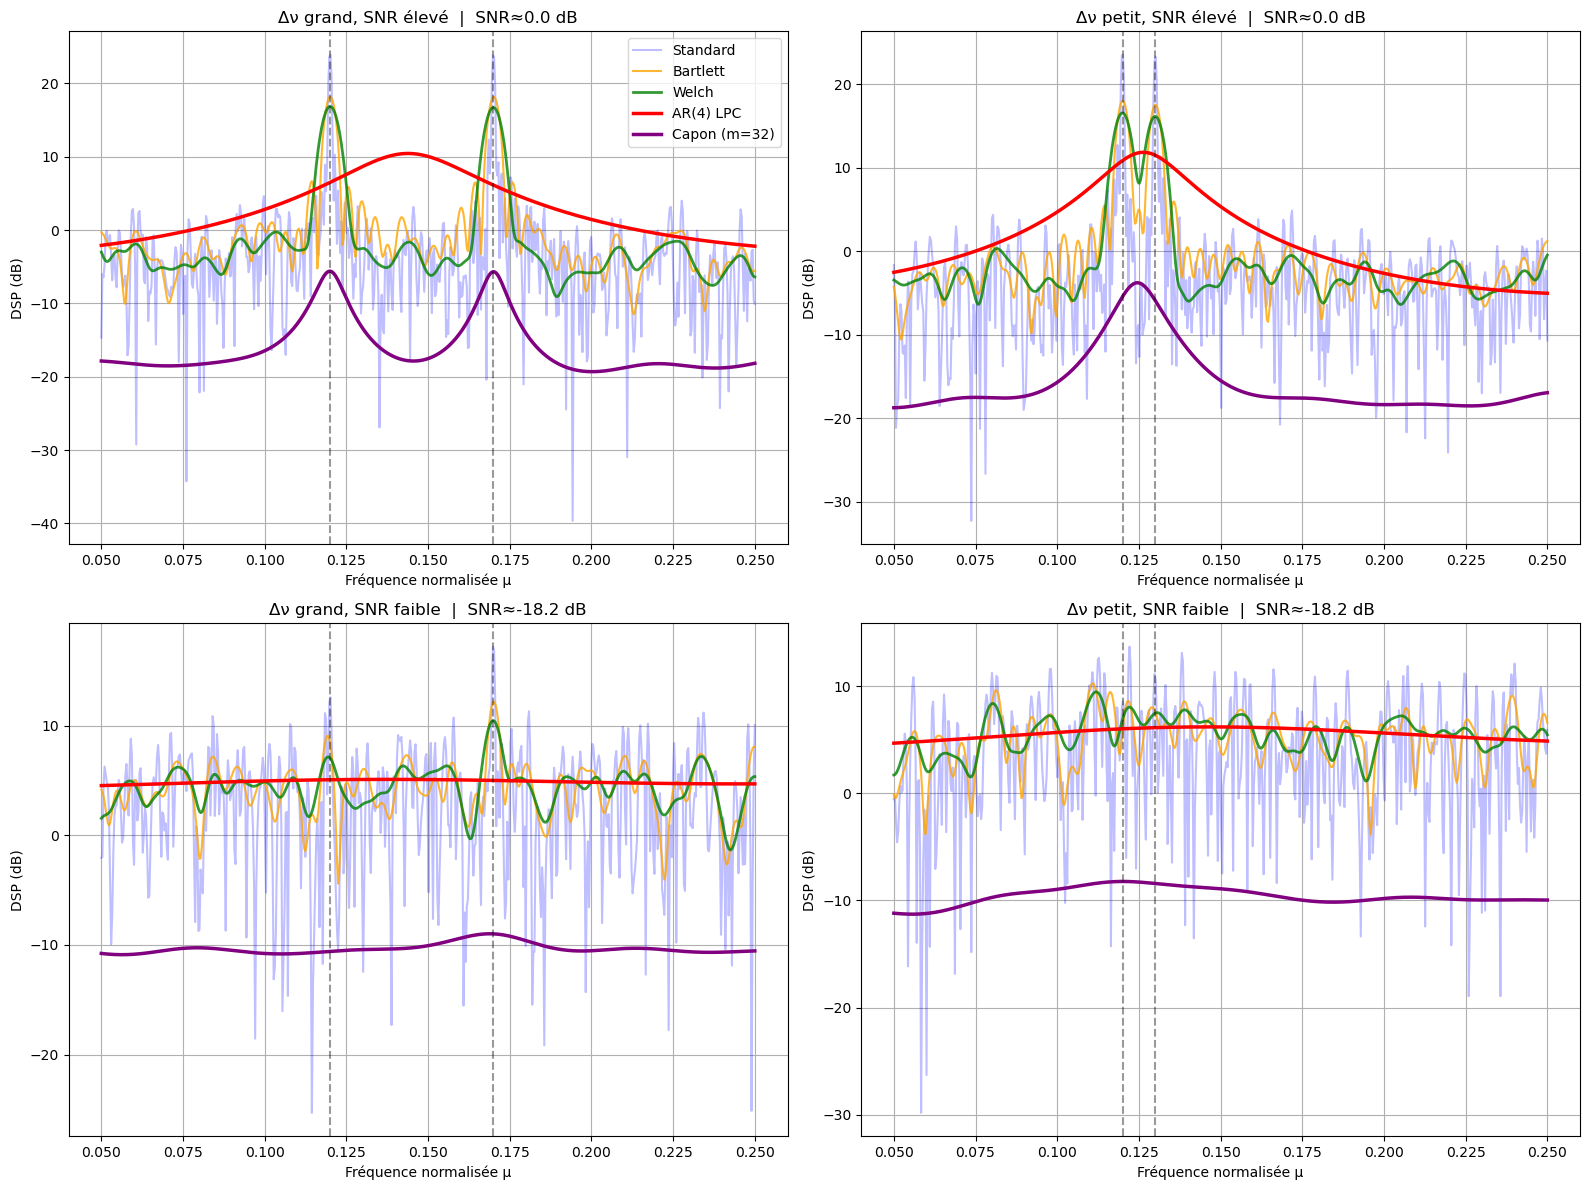

In [56]:
# Comparaison résolution (Δν) et SNR : Standard / Bartlett / Welch / AR(4) / Capon

N = 1000
L = 4
mu_values = np.linspace(0.05, 0.25, 600)
order_ar = 4
m_capon = 32

configs = [
    {"mu1": 0.12, "mu2": 0.17, "amp": 1.0, "var": 0.5, "title": "Δν grand, SNR élevé"},
    {"mu1": 0.12, "mu2": 0.13, "amp": 1.0, "var": 0.5, "title": "Δν petit, SNR élevé"},
    {"mu1": 0.12, "mu2": 0.17, "amp": 0.3, "var": 3.0, "title": "Δν grand, SNR faible"},
    {"mu1": 0.12, "mu2": 0.13, "amp": 0.3, "var": 3.0, "title": "Δν petit, SNR faible"},
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, conf in enumerate(configs):
    x = noisy_synthese(
        N,
        2,
        [conf["mu1"], conf["mu2"]],
        [conf["amp"], conf["amp"]],
        [0, 0],
        conf["var"],
    )

    Y_std = np.array([periodogram(x, False, False, mu, L) for mu in mu_values])
    Y_bart = np.array([periodogram(x, True, False, mu, L) for mu in mu_values])
    Y_welch = np.array([periodogram(x, False, True, mu, L) for mu in mu_values])

    # AR(4) LPC
    a_lpc = librosa.lpc(x, order=order_ar)
    residu = lfilter(a_lpc, [1.0], x)
    variance_estimee = np.var(residu)
    k = np.arange(len(a_lpc))
    exposant = -2 * 1j * np.pi * np.outer(mu_values, k)
    A_mu = np.dot(np.exp(exposant), a_lpc)
    psd_ar = variance_estimee / (np.abs(A_mu) ** 2)

    # Capon (MVDR)
    psd_capon = capon_spectrum(x, mu_values, m=m_capon, diagonal_loading=1e-3)

    axes[i].plot(mu_values, 10 * np.log10(Y_std + 1e-18), label="Standard", alpha=0.25, color="blue")
    axes[i].plot(mu_values, 10 * np.log10(Y_bart + 1e-18), label="Bartlett", linewidth=1.5, color="orange", alpha=0.8)
    axes[i].plot(mu_values, 10 * np.log10(Y_welch + 1e-18), label="Welch", linewidth=2, color="green", alpha=0.8)
    axes[i].plot(mu_values, 10 * np.log10(psd_ar + 1e-18), label=f"AR({order_ar}) LPC", linewidth=2.5, color="red")
    axes[i].plot(mu_values, 10 * np.log10(psd_capon + 1e-18), label=f"Capon (m={m_capon})", linewidth=2.5, color="purple")

    axes[i].axvline(conf["mu1"], color="black", linestyle="--", alpha=0.4)
    axes[i].axvline(conf["mu2"], color="black", linestyle="--", alpha=0.4)

    snr_db = 10 * np.log10((conf["amp"] ** 2) / (2 * conf["var"]))
    axes[i].set_title(f"{conf['title']}  |  SNR≈{snr_db:.1f} dB")
    axes[i].set_xlabel("Fréquence normalisée µ")
    axes[i].set_ylabel("DSP (dB)")
    axes[i].grid(True)
    if i == 0:
        axes[i].legend()

plt.tight_layout()
plt.show()

### Commentaire 

En pratique, Capon (MVDR) donne des pics beaucoup plus fins que les périodogrammes lissés (Bartlett/Welch) car il utilise l’inversion de la matrice de covariance pour “annuler” l’énergie hors direction/fréquence. En contrepartie, il est plus sensible à une mauvaise estimation de la covariance (peu d’échantillons, SNR faible)  d’où l’usage d’un diagonal loading pour stabiliser l’inversion.

## 3. Processus ARMA

### 3.1 Synthèse

On synthétise un ARMA(p,q) de longueur $N$ défini par ses coefficients AR/MA et la variance d’innovation $\sigma^2$ (voir `arma_synthesis`).

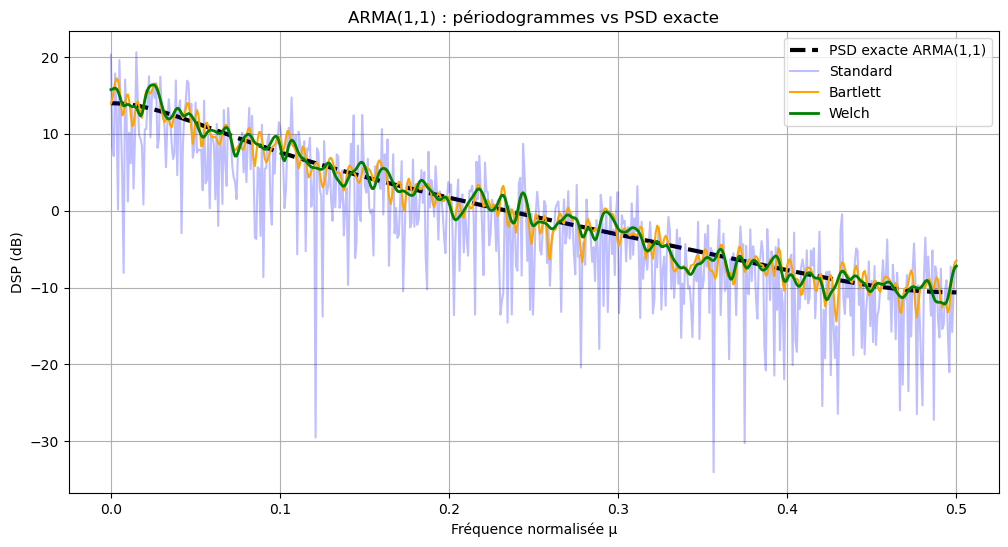

In [ ]:
# Exemple ARMA(1,1) : paramètres choisis à la main

N = 2048
ar = [0.7]   # AR(1)
ma = [0.5]   # MA(1)
sigma2 = 1.0

x_arma = arma_synthesis(N, ar=ar, ma=ma, sigma2=sigma2, burn_in=500)

mu_values = np.linspace(0, 0.5, 600, endpoint=False)
L = 8

Y_std = np.array([periodogram(x_arma, False, False, mu, L) for mu in mu_values])
Y_bart = np.array([periodogram(x_arma, True, False, mu, L) for mu in mu_values])
Y_welch = np.array([periodogram(x_arma, False, True, mu, L) for mu in mu_values])

S_exact = arma_psd(mu_values, ar=ar, ma=ma, sigma2=sigma2)

plt.figure(figsize=(12, 6))
plt.plot(mu_values, 10 * np.log10(S_exact + 1e-18), "k--", linewidth=3, label="PSD exacte ARMA(1,1)")
plt.plot(mu_values, 10 * np.log10(Y_std + 1e-18), color="blue", alpha=0.25, label="Standard")
plt.plot(mu_values, 10 * np.log10(Y_bart + 1e-18), color="orange", linewidth=1.5, label="Bartlett")
plt.plot(mu_values, 10 * np.log10(Y_welch + 1e-18), color="green", linewidth=2, label="Welch")
plt.title("ARMA(1,1) : périodogrammes vs PSD exacte")
plt.xlabel("Fréquence normalisée µ")
plt.ylabel("DSP (dB)")
plt.grid(True)
plt.legend()
plt.show()

In [58]:
# 3.3 Comparaison biais / variance (Monte-Carlo) sur l'ARMA(1,1)

N = 2048
ar = [0.7]
ma = [0.5]
sigma2 = 1.0

mu_values = np.linspace(0, 0.5, 200, endpoint=False)
L = 8
nb_realisations = 80

all_std = np.zeros((nb_realisations, mu_values.size))
all_bart = np.zeros((nb_realisations, mu_values.size))
all_welch = np.zeros((nb_realisations, mu_values.size))

for r in range(nb_realisations):
    x_arma = arma_synthesis(N, ar=ar, ma=ma, sigma2=sigma2, burn_in=500)
    for idx, mu in enumerate(mu_values):
        all_std[r, idx] = periodogram(x_arma, False, False, mu, L)
        all_bart[r, idx] = periodogram(x_arma, True, False, mu, L)
        all_welch[r, idx] = periodogram(x_arma, False, True, mu, L)

S_exact = arma_psd(mu_values, ar=ar, ma=ma, sigma2=sigma2).real

mean_std = np.mean(all_std, axis=0)
mean_bart = np.mean(all_bart, axis=0)
mean_welch = np.mean(all_welch, axis=0)

biais_std = float(np.mean(np.abs(mean_std - S_exact)))
biais_bart = float(np.mean(np.abs(mean_bart - S_exact)))
biais_welch = float(np.mean(np.abs(mean_welch - S_exact)))

var_std = float(np.mean(np.var(all_std, axis=0)))
var_bart = float(np.mean(np.var(all_bart, axis=0)))
var_welch = float(np.mean(np.var(all_welch, axis=0)))

print("ARMA(1,1) : comparaison biais/variance")
print(f"STANDARD : biais={biais_std:.4g} | var={var_std:.4g}")
print(f"BARTLETT : biais={biais_bart:.4g} | var={var_bart:.4g}")
print(f"WELCH    : biais={biais_welch:.4g} | var={var_welch:.4g}")

ARMA(1,1) : comparaison biais/variance
STANDARD : biais=0.3254 | var=57.44
BARTLETT : biais=0.121 | var=6.902
WELCH    : biais=0.1226 | var=4.307


### 3.3 Estimation paramétrique : méthode de Durbin

On applique `durbin_arma` pour estimer un modèle ARMA(p,q) (ici (1,1) pour l’exemple), puis on superpose :

- PSD exacte (modèle connu)
- Enveloppe spectrale du modèle ARMA estimé (Durbin)
- Périodogramme (Welch)

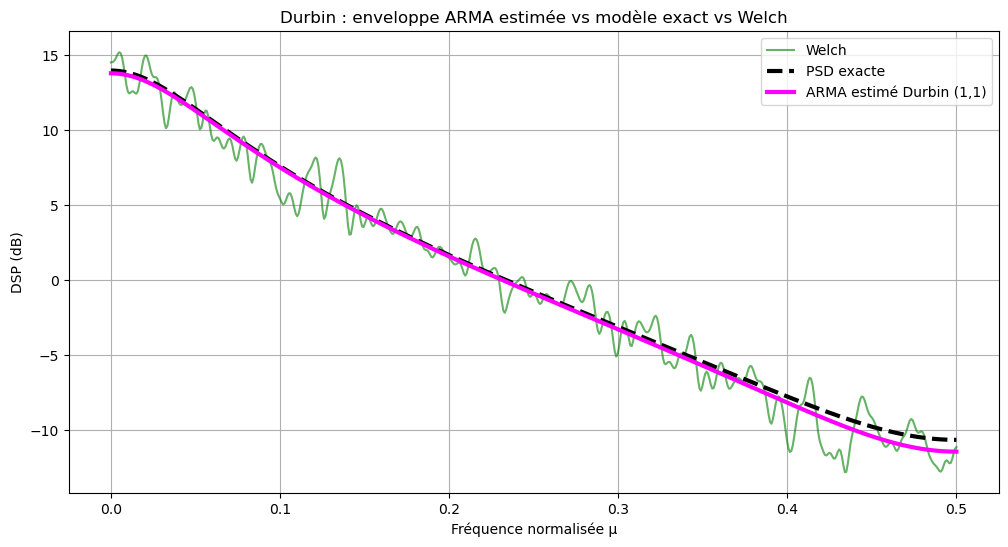

Paramètres vrais vs estimés
AR vrai=[0.7] | AR estimé=[0.6958]
MA vrai=[0.5] | MA estimé=[0.5314]
sigma2 vrai=1 | sigma2 estimé=0.945


In [ ]:
# Durbin ARMA(1,1) sur une réalisation : comparaison enveloppes

N = 2048
ar_true = [0.7]
ma_true = [0.5]
sigma2_true = 1.0

x_arma = arma_synthesis(N, ar=ar_true, ma=ma_true, sigma2=sigma2_true, burn_in=500)

p, q = 1, 1
ar_hat, ma_hat, sigma2_hat = durbin_arma(x_arma, p=p, q=q, ar_long=40)

mu_values = np.linspace(0, 0.5, 600, endpoint=False)
S_true = arma_psd(mu_values, ar_true, ma_true, sigma2_true)
S_hat = arma_psd(mu_values, ar_hat, ma_hat, sigma2_hat)

L = 8
Y_welch = np.array([periodogram(x_arma, False, True, mu, L) for mu in mu_values])

plt.figure(figsize=(12, 6))
plt.plot(mu_values, 10 * np.log10(Y_welch + 1e-18), color="green", alpha=0.6, label="Welch")
plt.plot(mu_values, 10 * np.log10(S_true + 1e-18), "k--", linewidth=3, label="PSD exacte")
plt.plot(mu_values, 10 * np.log10(S_hat + 1e-18), color="magenta", linewidth=3, label=f"ARMA estimé Durbin ({p},{q})")
plt.title("Durbin : enveloppe ARMA estimée vs modèle exact vs Welch")
plt.xlabel("Fréquence normalisée µ")
plt.ylabel("DSP (dB)")
plt.grid(True)
plt.legend()
plt.show()

print("Paramètres vrais vs estimés")
print(f"AR vrai={ar_true} | AR estimé={ar_hat.round(4).tolist()}")
print(f"MA vrai={ma_true} | MA estimé={ma_hat.round(4).tolist()}")
print(f"sigma2 vrai={sigma2_true:.3g} | sigma2 estimé={sigma2_hat:.3g}")

### Commentaire (Durbin)

- L’enveloppe ARMA estimée suit généralement mieux la PSD exacte que le périodogramme brut car on impose un modèle (faible variance), au prix d’un biais de modèle si les ordres (p,q) sont mal choisis.
- Quand $N$ est petit ou que le bruit est fort, l’estimation des autocorrélations et l’étape d’AR long peuvent dégrader l’estimation des paramètres MA (instabilité / coefficients peu fiables).

## 3.4 Application à un signal de parole (voyelle nasale)

On charge un extrait d’un fichier type `an_in_on.wav` (si disponible), on calcule un périodogramme (Welch) et on superpose une enveloppe paramétrique ARMA estimée (Durbin).

Loaded an_in_on.wav | sr=16000 | length=28270 samples


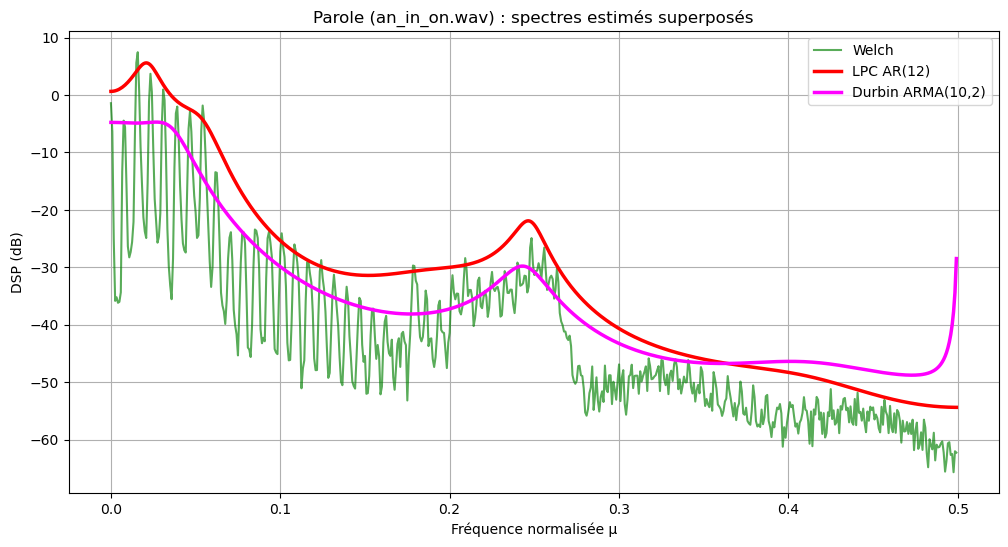

Durbin (speech) params summary
AR(p=10) first coeffs: [3.842, -1.852, -2.658, 2.149, -1.825] ...
MA(q=2) coeffs: [0.55, -0.367]


In [62]:
import os

# Essaie de charger le fichier demandé. Si absent, fallback sur aeiou.wav si présent.
candidate_files = ["an_in_on.wav", "an_in_on.WAV", "aeiou.wav"]
audio_path = next((f for f in candidate_files if os.path.exists(f)), None)

if audio_path is None:
    raise FileNotFoundError(
        "Aucun fichier audio trouvé. Place 'an_in_on.wav' (ou 'aeiou.wav') dans le dossier du notebook."
    )

y, sr = librosa.load(audio_path, sr=None)
print(f"Loaded {audio_path} | sr={sr} | length={len(y)} samples")

# Sélection d'un court extrait stable (évite l'attaque)
start = int(0.2 * sr) if len(y) > 0.3 * sr else 0
frame_len = int(0.5 * sr) if len(y) > start + 0.5 * sr else min(len(y) - start, 20000)
y_seg = y[start : start + frame_len]

# Estimation spectrale (on évite le point exact µ=0.5)
mu_values = np.linspace(0, 0.5, 600, endpoint=False)
L = 8

Y_welch = np.array([periodogram(y_seg, False, True, mu, L) for mu in mu_values])

# Durbin ARMA : choix d'ordres raisonnables pour parole (à ajuster)
p, q = 10, 2
ar_hat, ma_hat, sigma2_hat = durbin_arma(y_seg, p=p, q=q, ar_long=60)
S_arma_hat = arma_psd(mu_values, ar_hat, ma_hat, sigma2_hat)

# LPC (AR only) pour comparaison (déjà vu plus haut)
order_lpc = 12
a_lpc = librosa.lpc(y_seg, order=order_lpc)
residu = lfilter(a_lpc, [1.0], y_seg)
var_lpc = np.var(residu)
k = np.arange(len(a_lpc))
A_mu = np.dot(np.exp(-2 * 1j * np.pi * np.outer(mu_values, k)), a_lpc)
S_lpc = var_lpc / (np.abs(A_mu) ** 2)

plt.figure(figsize=(12, 6))
plt.plot(mu_values, 10 * np.log10(Y_welch + 1e-18), color="green", alpha=0.65, label="Welch")
plt.plot(mu_values, 10 * np.log10(S_lpc + 1e-18), color="red", linewidth=2.5, label=f"LPC AR({order_lpc})")
plt.plot(mu_values, 10 * np.log10(S_arma_hat + 1e-18), color="magenta", linewidth=2.5, label=f"Durbin ARMA({p},{q})")
plt.title(f"Parole ({audio_path}) : spectres estimés superposés")
plt.xlabel("Fréquence normalisée µ")
plt.ylabel("DSP (dB)")
plt.grid(True)
plt.legend()
plt.show()

print("Durbin (speech) params summary")
print(f"AR(p={p}) first coeffs: {ar_hat[:5].round(3).tolist()} ...")
print(f"MA(q={q}) coeffs: {ma_hat.round(3).tolist()}")